In [1]:
import torch
import torch.nn as nn
import kagglehub
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import copy
import seaborn as sns


/home/jcsf/miniconda3/envs/COMP372Assignments/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
IRIS_FOLDER = kagglehub.dataset_download("uciml/iris")
IRIS_CSV=os.path.join(IRIS_FOLDER, "Iris.csv")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)

In [3]:
df = pd.read_csv(IRIS_CSV)
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
# use a label encoder to conver the data into encoded values
le = LabelEncoder()

# convert features and labels into tensors
X = torch.tensor(df.drop(columns=["Id", "Species"]).values, dtype=torch.float32)
y_encoded = torch.tensor(le.fit_transform(df["Species"].values), dtype=torch.long)

# Create training, validation and test set
X_train, X_temp, y_train, y_temp = train_test_split(X, y_encoded, test_size=0.30, random_state=RANDOM_STATE, stratify=y_encoded)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

We create a new PyTorch Model representing the MLP inheriting defaults from the `nn.Module` class.

In [5]:
class MLP(nn.Module):
   def __init__(self):
      super(MLP, self).__init__()
      self.fc1 = nn.Linear(in_features=4, out_features=16)
      self.fc2 = nn.Linear(in_features=16, out_features=3)
   def forward(self, X):
      X = torch.relu(self.fc1(X))
      X = self.fc2(X)
      return X

In [6]:
learning_rate = 0.01
patience = 10

mlp = MLP()
optimizer = torch.optim.Adam(mlp.parameters(), lr=learning_rate)
loss = nn.CrossEntropyLoss()
training_loss = []
validation_loss = []

best_val_loss = float('inf')
best_mlp = None
curr_epoch = 0

while True:
    mlp.train()
    y_pred = mlp(X_train)
    tr_loss = loss(y_pred, y_train)
    optimizer.zero_grad()
    tr_loss.backward()
    optimizer.step()
    training_loss.append(tr_loss.item())
    
    mlp.eval()
    with torch.no_grad():
        y_pred = mlp(X_val)
        val_loss = loss(y_pred, y_val)
        validation_loss.append(val_loss.item())
        
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_mlp = copy.deepcopy(mlp)    
    else:
        patience_counter += 1
    
    if (curr_epoch+1) % 50 == 0 or patience_counter != 0: 
        print(f"Epoch {curr_epoch+1} -- Training loss:{tr_loss}, Validation loss: {val_loss}")
    
    curr_epoch += 1
    
    if patience_counter != 0:
        print(f"\tPatience counter {patience_counter}/{patience}")
        if patience_counter >= patience:
            break
        
print(f"Best model found at epoch {curr_epoch-patience}")
    

Epoch 50 -- Training loss:0.2761075794696808, Validation loss: 0.27847743034362793
Epoch 100 -- Training loss:0.09117894619703293, Validation loss: 0.10944094508886337
Epoch 150 -- Training loss:0.0645245686173439, Validation loss: 0.08216936141252518
Epoch 200 -- Training loss:0.05485553666949272, Validation loss: 0.07401775568723679
Epoch 238 -- Training loss:0.05004388839006424, Validation loss: 0.07241160422563553
	Patience counter 1/10
Epoch 241 -- Training loss:0.04970588535070419, Validation loss: 0.07240476459264755
	Patience counter 1/10
Epoch 242 -- Training loss:0.049594201147556305, Validation loss: 0.07241415977478027
	Patience counter 2/10
Epoch 243 -- Training loss:0.04948299005627632, Validation loss: 0.07242005318403244
	Patience counter 3/10
Epoch 244 -- Training loss:0.04937225952744484, Validation loss: 0.07242490351200104
	Patience counter 4/10
Epoch 245 -- Training loss:0.04926200211048126, Validation loss: 0.07243271917104721
	Patience counter 5/10
Epoch 246 -- T

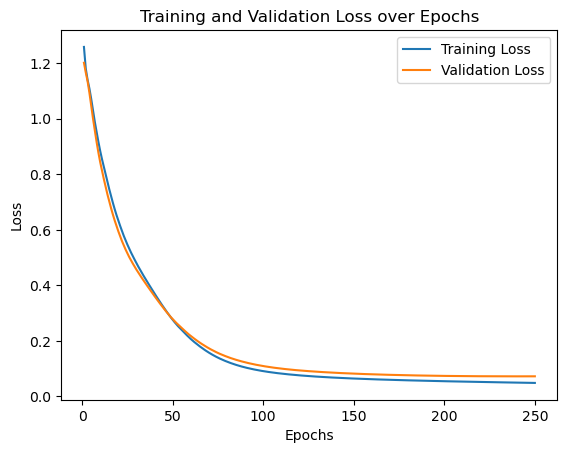

In [7]:
epochs = range(1, curr_epoch+1)
plt.plot(epochs, training_loss)
plt.plot(epochs, validation_loss)
plt.legend(["Training Loss", "Validation Loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss over Epochs")
plt.show()

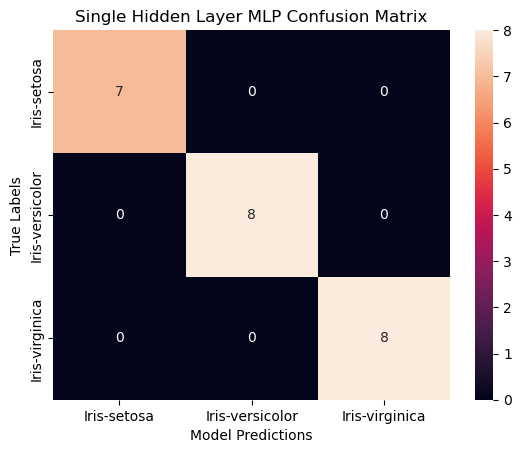

In [8]:
best_mlp.eval()
with torch.no_grad():
    y_pred = best_mlp(X_test)
    predictions = torch.argmax(y_pred, dim=1)

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel('Model Predictions')
plt.ylabel('True Labels')
plt.title('Single Hidden Layer MLP Confusion Matrix')
plt.show()

In [9]:
print(f"Accuracy score: {accuracy_score(y_test, predictions)*100}%")

Accuracy score: 100.0%
